# Our Journey

By: Nikolas Daskalpoulos and Adam Malyszko

### Mount Google Drive and Imports

In [ ]:
print("Hello Wolrd")

Hello Wolrd


In [ ]:
!pip install ultralytics
!pip install pyyaml
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

from google.colab import drive
import os
import pandas as pd
import ast
import cv2
import re
from google.colab.patches import cv2_imshow
from tqdm import tqdm
import concurrent.futures
from PIL import Image
from ultralytics import YOLO
import yaml
from collections import Counter
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import glob
import numpy as np
import shutil
import random


drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

# Pre - Processing

### Replace file label from .png to .jpg


Train

In [ ]:
csv_path = "/content/drive/MyDrive/ENDG511_Project_Data/labels/train.csv"
df = pd.read_csv(csv_path)

df["filename"] = df["filename"].str.replace(".png", ".jpg", regex=False)

updated_csv_path = "/content/drive/MyDrive/ENDG511_Project_Data/labels/train_updated.csv"
df.to_csv(updated_csv_path, index=False)

print("CSV updated and saved to:", updated_csv_path)

CSV updated and saved to: /content/drive/MyDrive/ENDG511_Project_Data/labels/train_updated.csv


Validation

In [ ]:
csv_path = "/content/drive/MyDrive/ENDG511_Project_Data/labels/val.csv"
df = pd.read_csv(csv_path)

df["filename"] = df["filename"].str.replace(".png", ".jpg", regex=False)

updated_csv_path = "/content/drive/MyDrive/ENDG511_Project_Data/labels/val_updated.csv"
df.to_csv(updated_csv_path, index=False)

print("CSV updated and saved to:", updated_csv_path)

Validate Bounding Box

In [ ]:
csv_file = "train_updated.csv"
image_folder = "/content/drive/MyDrive/ENDG511_Project_Data/train/"
output_folder = "/content/drive/MyDrive/ENDG511_Project_Data/labels/"
os.makedirs(output_folder, exist_ok=True)


def extract_number(filename):
    match = re.search(r"img(\d+)\.jpg", filename)
    return int(match.group(1)) if match else None


df = pd.read_csv(output_folder+csv_file)

threshold = 10

filtered_df = df[df["filename"].apply(lambda x: extract_number(x) is not None and extract_number(x) < threshold)]

class_list = df["class"].unique().tolist()

class_mapping = {class_name: index for index, class_name in enumerate(class_list)}
i=0

for _, row in filtered_df.iterrows():



    filename = row["filename"]
    img_path = os.path.join(image_folder, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load {img_path}. Skipping.")
        continue

    img_height, img_width, _ = img.shape
    bbox = ast.literal_eval(row["bbox"])

    #Bounding box stuff calcs
    x_min, y_min, x_max, y_max = bbox

    x_center = ((x_min + x_max) / 2) / img_width
    y_center = ((y_min + y_max) / 2) / img_height
    width = (x_max - x_min) / img_width
    height = (y_max - y_min) / img_height
    class_id = class_mapping[row["class"]]

    label_file = os.path.join(output_folder, filename.replace(".jpg", ".txt"))
    debug = img.copy()
    cv2.rectangle(debug, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    cv2_imshow(debug)
    cv2.waitKey(500)

    i=i+1
    if i>10:
      break

cv2.destroyAllWindows()
print("Conversion complete!")


## Converting NASA DATA to be compatible with YOLO

### Training

In [ ]:
csv_file = "train_updated.csv"
image_folder = "/content/drive/MyDrive/ENDG511_Project_Data/train/images"
label_folder = "/content/drive/MyDrive/ENDG511_Project_Data/labels/"
output_folder = "/content/drive/MyDrive/ENDG511_Project_Data/labels/YOLO_train/"
os.makedirs(output_folder, exist_ok=True)

#Loading CSV
df = pd.read_csv(os.path.join(label_folder, csv_file))
class_list = df["class"].unique().tolist()
class_mapping = {class_name: index for index, class_name in enumerate(class_list)}

#Processing YOLO label files
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    filename = row["filename"]
    img_path = os.path.join(image_folder, filename)
    label_file = os.path.join(output_folder, filename.replace(".jpg", ".txt"))

    # Skip if label file is already in folder
    # Allows for continuation of pervious processing that was cut s
    if os.path.exists(label_file):
        continue  # Skip if label file is already in folder - Allows for continuation of pervious processing that was cut short


    # Extract height and width
    with Image.open(img_path) as img:
        img_width, img_height = img.size


    bbox = ast.literal_eval(row["bbox"])


    #Getting values for the bounding box
    y_min, x_min, y_max, x_max = bbox

    #Yolo values
    x_center = ((x_min + x_max) / 2) / img_width
    y_center = ((y_min + y_max) / 2) / img_height
    width_norm = (x_max - x_min) / img_width
    height_norm = (y_max - y_min) / img_height
    class_id = class_mapping[row["class"]]


    with open(label_file, "w") as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")

print("Conversion complete!")

  0%|          | 83/66000 [00:19<4:24:02,  4.16it/s] 


KeyboardInterrupt: 

### Validation

In [ ]:
csv_file = "val_updated.csv"
image_folder = "/content/drive/MyDrive/ENDG511_Project_Data/val/images"
label_folder = "/content/drive/MyDrive/ENDG511_Project_Data/labels/"
output_folder = "/content/drive/MyDrive/ENDG511_Project_Data/labels/YOLO_val/"
os.makedirs(output_folder, exist_ok=True)

#Loading CSV
df = pd.read_csv(os.path.join(label_folder, csv_file))
class_list = df["class"].unique().tolist()
class_mapping = {class_name: index for index, class_name in enumerate(class_list)}

#Processing YOLO label files
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    filename = row["filename"]
    img_path = os.path.join(image_folder, filename)
    label_file = os.path.join(output_folder, filename.replace(".jpg", ".txt"))

    # Skip if label file is already in folder
    # Allows for continuation of pervious processing that was cut s
    if os.path.exists(label_file):
        continue  # Skip if label file is already in folder - Allows for continuation of pervious processing that was cut short


    # Extract height and width
    with Image.open(img_path) as img:
        img_width, img_height = img.size


    bbox = ast.literal_eval(row["bbox"])


    #Getting values for the bounding box
    y_min, x_min, y_max, x_max = bbox

    #Yolo values
    x_center = ((x_min + x_max) / 2) / img_width
    y_center = ((y_min + y_max) / 2) / img_height
    width_norm = (x_max - x_min) / img_width
    height_norm = (y_max - y_min) / img_height
    class_id = class_mapping[row["class"]]


    with open(label_file, "w") as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")

print("Conversion complete!")

# 1 Percent


## Training Setup

In [ ]:
x = 0.01
from tqdm import tqdm
# Define source and destination paths
train_path = "/content/drive/My Drive/ENDG511_Project_Data/train"
new_train_path = "/content/drive/My Drive/ENDG511_Project_Data/1percent/train"

imgs = os.path.join(train_path, "images")
labels = os.path.join(train_path, "labels")
new_imgs = os.path.join(new_train_path, "images")
new_labels = os.path.join(new_train_path, "labels")

# Ensure destination directories exist
os.makedirs(new_imgs, exist_ok=True)
os.makedirs(new_labels, exist_ok=True)

# Get a list of image files (ensuring only .jpg)
imgs_list = [f for f in tqdm(os.listdir(imgs)) if f.endswith(".jpg")]

# Select 1% of images randomly
copy_count = max(1, 3000)  # Ensure at least 1 file is copied
rand_imgs = random.sample(imgs_list, copy_count)

# Copy selected images and their corresponding labels
for new_img in tqdm(rand_imgs, desc="Copying files", unit="file"):
    img_path = os.path.join(imgs, new_img)
    label_path = os.path.join(labels, new_img.replace(".jpg", ".txt"))

    new_img_path = os.path.join(new_imgs, new_img)
    new_label_path = os.path.join(new_labels, new_img.replace(".jpg", ".txt"))

    shutil.copy(img_path, new_img_path)
    shutil.copy(label_path, new_label_path)

print(f"Copied {copy_count} images and labels successfully!")

## Validation Setup

In [ ]:
x = 0.01
from tqdm import tqdm
# Define source and destination paths
train_path = "/content/drive/My Drive/ENDG511_Project_Data/val"
new_train_path = "/content/drive/My Drive/ENDG511_Project_Data/1percent/val"

imgs = os.path.join(train_path, "images")
labels = os.path.join(train_path, "labels")
new_imgs = os.path.join(new_train_path, "images")
new_labels = os.path.join(new_train_path, "labels")

# Ensure destination directories exist
os.makedirs(new_imgs, exist_ok=True)
os.makedirs(new_labels, exist_ok=True)

# Get a list of image files (ensuring only .jpg)
imgs_list = [f for f in tqdm(os.listdir(imgs)) if f.endswith(".jpg")]

# Select 5% of images randomly
copy_count = max(1, 3000)  # Ensure at least 1 file is copied
rand_imgs = random.sample(imgs_list, copy_count)

# Copy selected images and their corresponding labels
for new_img in tqdm(rand_imgs, desc="Copying files", unit="file"):
    img_path = os.path.join(imgs, new_img)
    label_path = os.path.join(labels, new_img.replace(".jpg", ".txt"))

    new_img_path = os.path.join(new_imgs, new_img)
    new_label_path = os.path.join(new_labels, new_img.replace(".jpg", ".txt"))

    shutil.copy(img_path, new_img_path)
    shutil.copy(label_path, new_label_path)

print(f"Copied {copy_count} images and labels successfully!")

## Adjustments

Swap label indices

In [ ]:
import os

def rearrange_values(file_path, new_order):
    with open(file_path, 'r') as f:
        values = f.readline().strip().split()

    rearranged = [values[i] for i in new_order]  # Rejoice!

    with open(file_path, 'w') as f:
        f.write(' '.join(rearranged))  # Send back the good order

#Re-ordering Validation Labels
file_path = "/content/drive/MyDrive/ENDG511_Project_Data/1percent/val/labels/"
txt_files = [f for f in tqdm(os.listdir(file_path))]

#Re-ordering Training Labels
file_patht = "/content/drive/MyDrive/ENDG511_Project_Data/1percent/train/labels/"
txt_filest = [f for f in tqdm(os.listdir(file_patht))]

new_order = [0, 2, 1, 4, 3]


#Loop all files
for txt_file in txt_filest:
    full_file_path = os.path.join(file_patht, txt_file)
    rearrange_values(full_file_path, new_order)


 #Loop all files
for txt_file in txt_files:
    full_file_path = os.path.join(file_path, txt_file)
    rearrange_values(full_file_path, new_order)





100%|██████████| 9000/9000 [00:00<00:00, 3575706.73it/s]


Adjust Validation Labels

In [ ]:
val_label_dir = "/content/drive/MyDrive/ENDG511_Project_Data/1percent/val/labels/"

id_remap = {0: 2, 1: 5, 2: 0, 3: 9, 4: 6, 5: 7, 6: 3, 7: 8, 8: 4, 9: 1, 10: 10}

label_files = os.listdir(val_label_dir)

for file_name in tqdm(label_files):
  with open(os.path.join(val_label_dir, file_name), "r") as file:
    line = file.readlines()

  new_line = []

  parts = line[0].strip().split()

  old_class_id = int(parts[0])

  new_class_id = id_remap[old_class_id]

  parts[0] = str(new_class_id)

  new_line.append(" ".join(parts) + "\n")

  with open(os.path.join(val_label_dir, file_name), "w") as file:
    file.writelines(new_line)

## Plot Class Distribution

100%|██████████| 660/660 [00:13<00:00, 47.49it/s] 


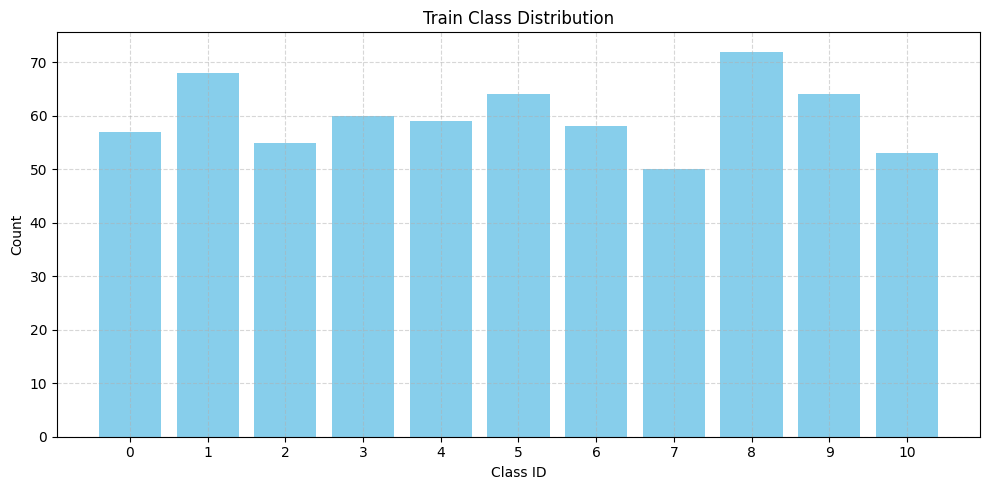

100%|██████████| 220/220 [00:05<00:00, 39.53it/s] 


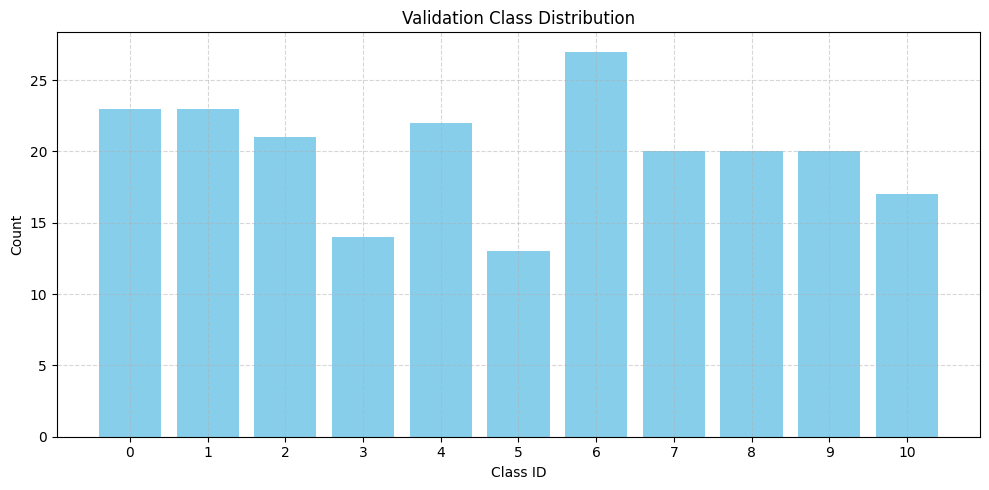

In [ ]:
def plot_class_distribution(label_dir, title="Class Distribution"):
    label_files = os.listdir(label_dir)
    class_counts = Counter()

    for label_file in tqdm(label_files):
        with open(os.path.join(label_dir, label_file), 'r') as f:
            line = f.readlines()


        parts = line[0].strip().split()

        class_id = int(parts[0])

        class_counts[class_id] += 1

    # Plotting
    classes = list(class_counts.keys())
    counts = [class_counts[cls] for cls in classes]

    plt.figure(figsize=(10, 5))
    plt.bar(classes, counts, color='skyblue')
    plt.xticks(classes)
    plt.xlabel("Class ID")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# === Example use ===
plot_class_distribution(
    label_dir="/content/drive/MyDrive/ENDG511_Project_Data/1percent/train/labels",
    title="Train Class Distribution"
)

plot_class_distribution(
    label_dir="/content/drive/MyDrive/ENDG511_Project_Data/1percent/val/labels",
    title="Validation Class Distribution"
)

## Create .yaml File


In [ ]:
#Loadin the CSV
df = pd.read_csv(os.path.join("/content/drive/MyDrive/ENDG511_Project_Data/labels/" , 'train_updated.csv'))
class_list = df["class"].unique().tolist()
print(class_list)


dataset_config = {
    'train': '/content/drive/MyDrive/ENDG511_Project_Data/1percent/train/images/',
    'val': '/content/drive/MyDrive/ENDG511_Project_Data/1percent/val/images/',
    'nc': 11,
    'names': class_list
}

#Writing the way to the YAML file
import yaml

yaml_path = '/content/drive/MyDrive/ENDG511_Project_Data/1percentdataset_1class.yaml'
with open(yaml_path, 'w') as file:
    yaml.dump(dataset_config, file, default_flow_style=False)

print("YAML file created at:", yaml_path)

['smart_1', 'cheops', 'lisa_pathfinder', 'debris', 'proba_3_ocs', 'proba_3_csc', 'soho', 'earth_observation_sat_1', 'proba_2', 'xmm_newton', 'double_star']
YAML file created at: /content/drive/MyDrive/ENDG511_Project_Data/9000images/dataset_9000.yaml


## Train

In [ ]:
model = YOLO("yolov8n.pt")
pt_model = model.model
print(pt_model)


yaml_path = '/content/drive/MyDrive/ENDG511_Project_Data/1percent/dataset_1class.yaml'

model.train(data = yaml_path,
            epochs=5,
            imgsz=640,
            lr0=0.01,
            lrf=0.0001,
            augment=True,
            batch=16,
            project='/content/drive/MyDrive/ENDG511_Project_Data/1percent/models30',  # New: Specify your desired save path
            name='model1_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=16')  # New: Set a custom name for the training run folder

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

train: Scanning /content/drive/MyDrive/ENDG511_Project_Data/train/labels... 2293 images, 0 backgrounds, 0 corrupt:   3%|▎         | 2293/66000 [28:19<1108:16:53, 62.63s/it]

## Continue from trained model

In [ ]:
model = YOLO("runs/detect/train/weights/last.pt")  # Load the last checkpoint
model.train(data=yaml_path,
            epochs=80,
            imgsz=640,
            lr0=0.01,
            lrf=0.0001,
            augment=True,
            batch=16,
            project='/content/drive/MyDrive/ENDG511_Project_Data/1percent/models30',  # New: Specify your desired save path
            name='model1_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=16')  # New: Set a custom name for the training run folder)  # Set total target epochs



FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights/last.pt'

# Largest 10% Bounding Boxes

## Filter only largest bounding boxes

In [ ]:
import os
import shutil

def filter_largest_bboxes(label_dir, image_dir, output_label_dir, output_image_dir, top_percent=0.1):
    os.makedirs(output_label_dir, exist_ok=True)
    os.makedirs(output_image_dir, exist_ok=True)

    label_files = os.listdir(label_dir)
    file_area = []

    # Determine normalized bounding box label per txt file
    for label_file in tqdm(label_files):
        with open(os.path.join(label_dir,label_file), 'r') as f:
            line = f.readlines()

        max_area = 0

        parts = line[0].strip().split()

        _, _, _, width, height = map(float, parts)
        area = width * height  # Normalized area

        file_area.append((label_file, area))

    # sort by area and keep top bounding boxes
    file_area.sort(key=lambda x: x[1], reverse=True)
    num_to_keep = int(len(file_area) * top_percent)
    top_files = file_area[:num_to_keep]


    # Copy selected labels and images to new directory
    for label_file, _ in tqdm(top_files):

        image_filename = label_file.replace(".txt", ".jpg")

        #label
        shutil.copy(os.path.join(label_dir,label_file), os.path.join(output_label_dir, label_file))


        #image
        shutil.copy(os.path.join(image_dir, image_filename), os.path.join(output_image_dir, image_filename))

# Train
filter_largest_bboxes(
    "/content/drive/MyDrive/ENDG511_Project_Data/train/labels/",
    "/content/drive/MyDrive/ENDG511_Project_Data/train/images/",
    "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/train/labels/",
    "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/train/images/"
)

# Validation
filter_largest_bboxes(
    "/content/drive/MyDrive/ENDG511_Project_Data/val/labels/",
    "/content/drive/MyDrive/ENDG511_Project_Data/val/images/",
    "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/val/labels/",
    "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/val/images/"
)

## Adjustments

Swap label indices

In [ ]:
import os

def rearrange_values(file_path, new_order):
    with open(file_path, 'r') as f:
        values = f.readline().strip().split()

    rearranged = [values[i] for i in new_order]  # Rejoice!

    with open(file_path, 'w') as f:
        f.write(' '.join(rearranged))  # Send back the good order

#Re-ordering Validation Labels
file_path = "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/val/labels/"
txt_files = [f for f in tqdm(os.listdir(file_path))]

#Re-ordering Training Labels
file_patht = "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/train/labels/"
txt_filest = [f for f in tqdm(os.listdir(file_patht))]

new_order = [0, 2, 1, 4, 3]


#Loop all files
for txt_file in txt_filest:
    full_file_path = os.path.join(file_patht, txt_file)
    rearrange_values(full_file_path, new_order)


 #Loop all files
for txt_file in txt_files:
    full_file_path = os.path.join(file_path, txt_file)
    rearrange_values(full_file_path, new_order)





100%|██████████| 9000/9000 [00:00<00:00, 3575706.73it/s]


Adjust Validation Labels

In [ ]:
val_label_dir = "/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/val/labels/"

id_remap = {0: 2, 1: 5, 2: 0, 3: 9, 4: 6, 5: 7, 6: 3, 7: 8, 8: 4, 9: 1, 10: 10}

label_files = os.listdir(val_label_dir)

for file_name in tqdm(label_files):
  with open(os.path.join(val_label_dir, file_name), "r") as file:
    line = file.readlines()

  new_line = []

  parts = line[0].strip().split()

  old_class_id = int(parts[0])

  new_class_id = id_remap[old_class_id]

  parts[0] = str(new_class_id)

  new_line.append(" ".join(parts) + "\n")

  with open(os.path.join(val_label_dir, file_name), "w") as file:
    file.writelines(new_line)

## Plot Class Distribution

100%|██████████| 660/660 [00:14<00:00, 44.76it/s] 


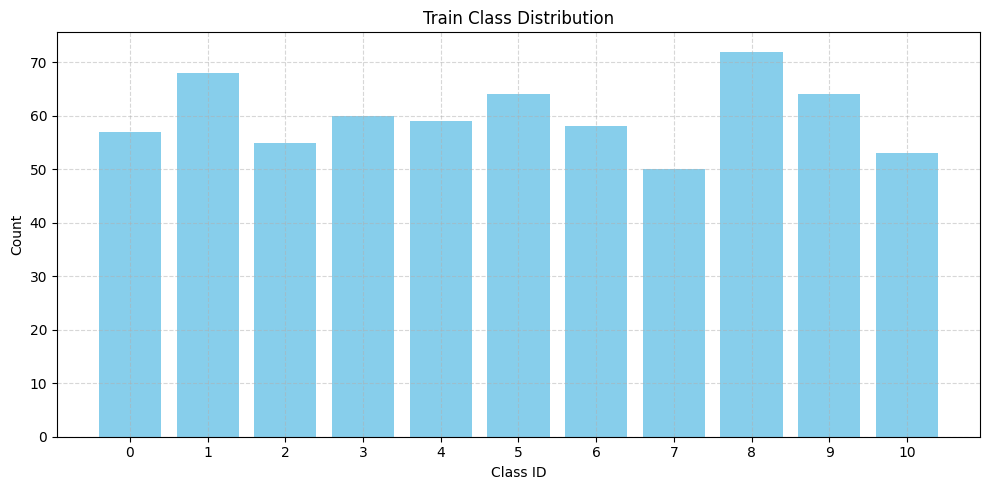

100%|██████████| 220/220 [00:04<00:00, 45.28it/s] 


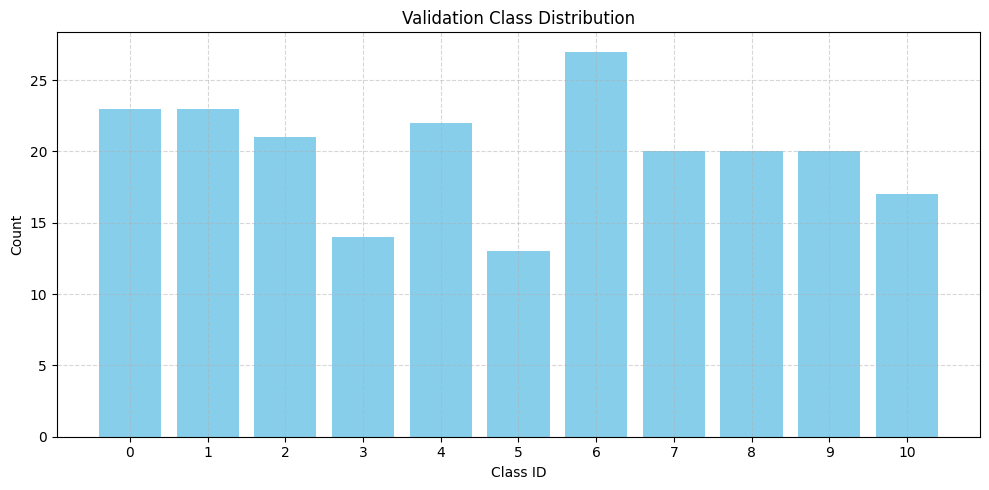

In [ ]:
def plot_class_distribution(label_dir, title="Class Distribution"):
    label_files = os.listdir(label_dir)
    class_counts = Counter()

    for label_file in tqdm(label_files):
        with open(os.path.join(label_dir, label_file), 'r') as f:
            line = f.readlines()


        parts = line[0].strip().split()

        class_id = int(parts[0])

        class_counts[class_id] += 1

    # Plotting
    classes = list(class_counts.keys())
    counts = [class_counts[cls] for cls in classes]

    plt.figure(figsize=(10, 5))
    plt.bar(classes, counts, color='skyblue')
    plt.xticks(classes)
    plt.xlabel("Class ID")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# === Example use ===
plot_class_distribution(
    label_dir="/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/train/labels",
    title="Train Class Distribution"
)

plot_class_distribution(
    label_dir="/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/val/labels",
    title="Validation Class Distribution"
)

## Create .yaml File


In [ ]:
#Loadin the CSV
df = pd.read_csv(os.path.join("/content/drive/MyDrive/ENDG511_Project_Data/labels/" , 'train_updated.csv'))
class_list = df["class"].unique().tolist()
print(class_list)


dataset_config = {
    'train': '/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/train/images/',
    'val': '/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/val/images/',
    'nc': 11,
    'names': class_list
}

#Writing the way to the YAML file
import yaml

yaml_path = '/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/dataset_1class.yaml'
with open(yaml_path, 'w') as file:
    yaml.dump(dataset_config, file, default_flow_style=False)

print("YAML file created at:", yaml_path)

['smart_1', 'cheops', 'lisa_pathfinder', 'debris', 'proba_3_ocs', 'proba_3_csc', 'soho', 'earth_observation_sat_1', 'proba_2', 'xmm_newton', 'double_star']
YAML file created at: /content/drive/MyDrive/ENDG511_Project_Data/9000images/dataset_9000.yaml


## Train

In [ ]:
model = YOLO("yolov8n.pt")
pt_model = model.model
print(pt_model)


yaml_path = '/content/drive/MyDrive/ENDG511_Project_Data/BIG BOX/dataset_1class.yaml'

model.train(data = yaml_path,
            epochs=5,
            imgsz=640,
            lr0=0.01,
            lrf=0.0001,
            augment=True,
            batch=16,
            project='/content/drive/MyDrive/ENDG511_Project_Data/BIG BOXimages/models30',  # New: Specify your desired save path
            name='model1_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=16')  # New: Set a custom name for the training run folder

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

train: Scanning /content/drive/MyDrive/ENDG511_Project_Data/train/labels... 2293 images, 0 backgrounds, 0 corrupt:   3%|▎         | 2293/66000 [28:19<1108:16:53, 62.63s/it]

## Continue from trained model

In [ ]:
model = YOLO("runs/detect/train/weights/last.pt")  # Load the last checkpoint
model.train(data=yaml_path,
            epochs=80,
            imgsz=640,
            lr0=0.01,
            lrf=0.0001,
            augment=True,
            batch=16,
            project='/content/drive/MyDrive/ENDG511_Project_Data/Big BOX/models30',  # New: Specify your desired save path
            name='model1_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=16')  # New: Set a custom name for the training run folder)  # Set total target epochs



FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights/last.pt'

# 9000 Images (Based on Convergence Study)

## Training Setup (11000)

In [ ]:
train_path = "/content/drive/My Drive/ENDG511_Project_Data/train"
new_train_path = "/content/drive/My Drive/ENDG511_Project_Data/9000/train"


imgs = os.path.join(train_path, "images")
labels = os.path.join(train_path, "labels")
new_imgs = os.path.join(new_train_path, "images")
new_labels = os.path.join(new_train_path, "labels")


os.makedirs(new_imgs, exist_ok=True)
os.makedirs(new_labels, exist_ok=True)

In [ ]:

imgs_list = [f for f in os.listdir(imgs)]

copy = 9000
rand_imgs = random.sample(imgs_list, copy)


for new_img in tqdm(rand_imgs):
    img_path = os.path.join(imgs, new_img)
    label_path = os.path.join(labels, new_img.replace(".jpg", ".txt"))

    new_img_path = os.path.join(new_imgs, new_img)
    new_label_path = os.path.join(new_labels, new_img.replace(".jpg", ".txt"))


    shutil.copy(img_path, new_img_path)
    shutil.copy(label_path, new_label_path)

100%|██████████| 9000/9000 [3:14:32<00:00,  1.30s/it]


In [ ]:
print(len(os.listdir(new_imgs)))
print(len(os.listdir(new_labels)))

11616
11616


## Validation Setup (3000)

In [ ]:
val_path = "/content/drive/My Drive/ENDG511_Project_Data/val"
new_val_path = "/content/drive/My Drive/ENDG511_Project_Data/9000/val"


imgs = os.path.join(val_path, "images")
labels = os.path.join(val_path, "labels")
new_imgs = os.path.join(new_val_path, "images")
new_labels = os.path.join(new_val_path, "labels")

In [ ]:

imgs_list = [f for f in os.listdir(imgs)]

copy = 3000
rand_imgs = random.sample(imgs_list, copy)


for new_img in rand_imgs:
    img_path = os.path.join(imgs, new_img)
    label_path = os.path.join(labels, new_img.replace(".jpg", ".txt"))

    new_img_path = os.path.join(new_imgs, new_img)
    new_label_path = os.path.join(new_labels, new_img.replace(".jpg", ".txt"))

    shutil.copy(img_path, new_img_path)
    shutil.copy(label_path, new_label_path)

In [ ]:
print(len(os.listdir(new_imgs)))
print(len(os.listdir(new_labels)))

3000
3000


## Adjustments

Swap label indices

In [ ]:
import os

def rearrange_values(file_path, new_order):
    with open(file_path, 'r') as f:
        values = f.readline().strip().split()

    rearranged = [values[i] for i in new_order]  # Rejoice!

    with open(file_path, 'w') as f:
        f.write(' '.join(rearranged))  # Send back the good order

#Re-ordering Validation Labels
file_path = "/content/drive/MyDrive/ENDG511_Project_Data/9000/val/labels/"
txt_files = [f for f in tqdm(os.listdir(file_path))]

#Re-ordering Training Labels
file_patht = "/content/drive/MyDrive/ENDG511_Project_Data/9000/train/labels/"
txt_filest = [f for f in tqdm(os.listdir(file_patht))]

new_order = [0, 2, 1, 4, 3]


#Loop all files
for txt_file in txt_filest:
    full_file_path = os.path.join(file_patht, txt_file)
    rearrange_values(full_file_path, new_order)


 #Loop all files
for txt_file in txt_files:
    full_file_path = os.path.join(file_path, txt_file)
    rearrange_values(full_file_path, new_order)





100%|██████████| 11616/11616 [00:00<00:00, 4237717.25it/s]


Adjust Validation Labels

In [ ]:
val_label_dir = "/content/drive/MyDrive/ENDG511_Project_Data/9000/val/labels/"

id_remap = {0: 2, 1: 5, 2: 0, 3: 9, 4: 6, 5: 7, 6: 3, 7: 8, 8: 4, 9: 1, 10: 10}

label_files = os.listdir(val_label_dir)

for file_name in tqdm(label_files):
  with open(os.path.join(val_label_dir, file_name), "r") as file:
    line = file.readlines()

  new_line = []

  parts = line[0].strip().split()

  old_class_id = int(parts[0])

  new_class_id = id_remap[old_class_id]

  parts[0] = str(new_class_id)

  new_line.append(" ".join(parts) + "\n")

  with open(os.path.join(val_label_dir, file_name), "w") as file:
    file.writelines(new_line)

100%|██████████| 3000/3000 [02:18<00:00, 21.69it/s]


## Plot Class Distribution

In [ ]:
def plot_class_distribution(label_dir, title="Class Distribution"):
    label_files = os.listdir(label_dir)
    class_counts = Counter()

    for label_file in tqdm(label_files):
        with open(os.path.join(label_dir, label_file), 'r') as f:
            line = f.readlines()


        parts = line[0].strip().split()

        class_id = int(parts[0])

        class_counts[class_id] += 1

    # Plotting
    classes = list(class_counts.keys())
    counts = [class_counts[cls] for cls in classes]

    plt.figure(figsize=(10, 5))
    plt.bar(classes, counts, color='skyblue')
    plt.xticks(classes)
    plt.xlabel("Class ID")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# === Example use ===
plot_class_distribution(
    label_dir="/content/drive/MyDrive/ENDG511_Project_Data/9000/train/labels",
    title="Train Class Distribution"
)

plot_class_distribution(
    label_dir="/content/drive/MyDrive/ENDG511_Project_Data/9000/val/labels",
    title="Validation Class Distribution"
)

KeyboardInterrupt: 

## Create .yaml File


In [ ]:
#Loadin the CSV
df = pd.read_csv(os.path.join("/content/drive/MyDrive/ENDG511_Project_Data/labels/" , 'train_updated.csv'))
class_list = df["class"].unique().tolist()
print(class_list)


dataset_config = {
    'train': '/content/drive/MyDrive/ENDG511_Project_Data/9000/train/images/',
    'val': '/content/drive/MyDrive/ENDG511_Project_Data/9000/val/images/',
    'nc': 11,
    'names': class_list
}

yaml_path = '/content/drive/MyDrive/ENDG511_Project_Data/9000/dataset_1class.yaml'
with open(yaml_path, 'w') as file:
    yaml.dump(dataset_config, file, default_flow_style=False)

print("YAML file created at:", yaml_path)

['smart_1', 'cheops', 'lisa_pathfinder', 'debris', 'proba_3_ocs', 'proba_3_csc', 'soho', 'earth_observation_sat_1', 'proba_2', 'xmm_newton', 'double_star']
YAML file created at: /content/drive/MyDrive/ENDG511_Project_Data/9000/dataset_1class.yaml


## Train

In [ ]:
model = YOLO("yolov8n.pt")
pt_model = model.model
print(pt_model)


yaml_path = '/content/drive/MyDrive/ENDG511_Project_Data/9000/dataset_1class.yaml'

model.train(data = yaml_path,
            epochs=1,
            imgsz=640,
            lr0=0.01,
            lrf=0.0001,
            augment=True,
            batch=16,
            project='/content/drive/MyDrive/ENDG511_Project_Data/9000/models30',  # New: Specify your desired save path
            name='model3_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=16')  # New: Set a custom name for the training run folder

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

train: Scanning /content/drive/MyDrive/ENDG511_Project_Data/9000/train/labels.cache... 11616 images, 0 backgrounds, 0 corrupt: 100%|██████████| 11616/11616 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/ENDG511_Project_Data/9000/val/labels.cache... 3000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3000/3000 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/ENDG511_Project_Data/9000/models30/model3_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=164/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /content/drive/MyDrive/ENDG511_Project_Data/9000/models30/model3_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=164
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1      2.99G      1.562      3.742      1.547         36        640: 100%|██████████| 726/726 [01:21<00:00,  8.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 94/94 [00:58<00:00,  1.60it/s]


                   all       3000       3000     0.0057    0.00914   0.000985   0.000219

1 epochs completed in 0.041 hours.
Optimizer stripped from /content/drive/MyDrive/ENDG511_Project_Data/9000/models30/model3_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=164/weights/last.pt, 6.2MB
Optimizer stripped from /content/drive/MyDrive/ENDG511_Project_Data/9000/models30/model3_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=164/weights/best.pt, 6.2MB

Validating /content/drive/MyDrive/ENDG511_Project_Data/9000/models30/model3_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=164/weights/best.pt...
Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 94/94 [00:17<00:00,  5.49it/s]


                   all       3000       3000    0.00535     0.0132      0.001   0.000234
               smart_1        276        276          0          0   0.000153   4.48e-05
                cheops        255        255     0.0222      0.051    0.00341   0.000758
       lisa_pathfinder        300        300          0          0   0.000119   3.39e-05
                debris        285        285   0.000824    0.00351   0.000119   3.72e-05
           proba_3_ocs        263        263          0          0   0.000271    9.5e-05
           proba_3_csc        278        278          0          0   0.000154   3.03e-05
                  soho        281        281          0          0   1.36e-05   4.73e-06
earth_observation_sat_1        271        271          0          0   0.000762    0.00019
               proba_2        260        260    0.00494     0.0192    0.00105   0.000311
            xmm_newton        251        251          0          0   0.000376   0.000131
           double_st

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d33a00ae610>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

## Continue from trained model

In [ ]:
model = YOLO("runs/detect/train/weights/last.pt")  # Load the last checkpoint
model.train(data=yaml_path,
            epochs=80,
            imgsz=640,
            lr0=0.01,
            lrf=0.0001,
            augment=True,
            batch=16,
            project='/content/drive/MyDrive/ENDG511_Project_Data/9000/models30',  # New: Specify your desired save path
            name='model1_imgsz=640_lr=0.01_lrf=0.0001_augment=1_batch=16')  # New: Set a custom name for the training run folder)  # Set total target epochs



FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights/last.pt'

# PCA

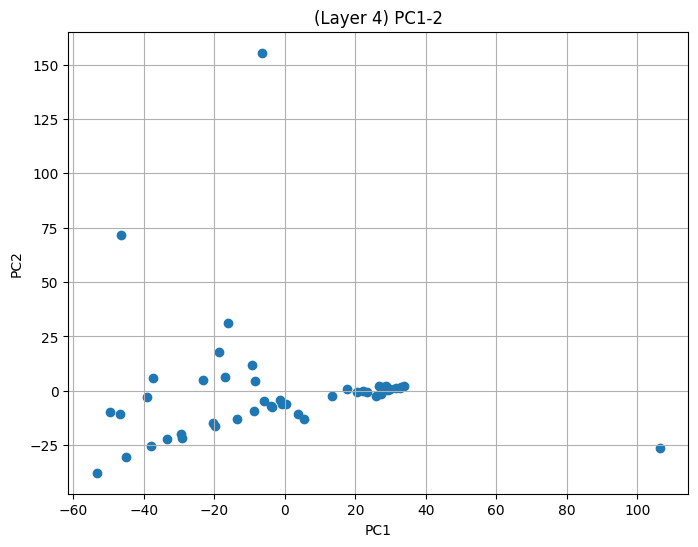

Explained Variance Ratio: [   0.054251    0.045905    0.036363]
Cumulative Variance: [   0.054251     0.10016     0.13652]


In [ ]:
# Load YOLOv8 model
model = YOLO("yolov8n.pt")
pt_model = model.model
features = []
image_names = []

# Hook function to extract features
def hook_fn(module, input, output):
    features.append(output.cpu().detach().flatten(1))

# Apply hook to layer 4
hook = pt_model.model[4].register_forward_hook(hook_fn)

# Path to dataset
image_dir = "/content/drive/MyDrive/ENDG511_Project_Data/1percent/train/images"
image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir)]

# Forward pass on 50 images
for img_path in image_paths[:50]:
    img = cv2.imread(img_path) # Load image with cv2 in (Hieght, Width, Channel (BGR)) format
    img = cv2.resize(img, (640, 640)) # Resize images to YOLO expected image size

    # reverses channel input from BGR to RGB and image input from (H W C) to (C H W) for pytorch compatibility
    img = img[:, :, ::-1].transpose(2, 0, 1).copy()

    # Converts image to Pytorch Tensor of floating point numbers,
    # adds batch dimension, and normalizes RGB data
    img = torch.tensor(img).float().unsqueeze(0) / 255.0

    with torch.no_grad():
        pt_model(img)  # Hook captures the features

    image_names.append(os.path.basename(img_path))  # Save image name for later

# Remove hook
hook.remove()


X = torch.cat(features).numpy() # Concatenates images along batch dimension so size(1, 423) -> size(50,423) for example
pca = PCA(n_components=3) # Sets up 3 principal components
X_pca = pca.fit_transform(X) # fits pca to X to reduce dimensionality of feature vector to just 3 dimensions size(50, 423) -> size(3,423)


# Plots PC1 vs PC2
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 1], X_pca[:, 2])
plt.title("(Layer 4) PC1-2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()



#Convergence studies

In [ ]:

image_dir = "/content/drive/MyDrive/ENDG511_Project_Data/train/images"
chunk_output_dir = "/content/drive/MyDrive/ENDG511_Project_Data/Convergence Studies/feature chunks"
save_path = "/content/drive/MyDrive/ENDG511_Project_Data/Convergence Studies/yolo_features_test.npy"
name_path = "/content/drive/MyDrive/ENDG511_Project_Data/Convergence Studies/image_test.npy"
image_paths_file = os.path.join(chunk_output_dir, "image_paths.npy")
chunk_size = 5000
layer_index = 5
imgsz = 640
max_images = 66000

random.seed(42)
np.random.seed(42)


In [ ]:

model = YOLO("yolov8n.pt")
pt_model = model.model.eval()

100%|██████████| 6.25M/6.25M [00:00<00:00, 16.7MB/s]


## Create Feature Chunks

In [ ]:
# Create feature chunks in drive due to large runtime and reusability

image_paths_file = os.path.join(chunk_output_dir, "image_paths.npy")
if os.path.exists(image_paths_file):
    image_paths = np.load(image_paths_file, allow_pickle=True).tolist()
else:
    image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir)]
    image_paths = random.sample(image_paths, min(max_images, len(image_paths)))
    np.save(image_paths_file, np.array(image_paths))


## Extract Features for each chunk

In [ ]:
#Feature extraction per chunk
total_chunks = len(image_paths) // chunk_size + int(len(image_paths) % chunk_size != 0)
layer_index = 5
imgsz = 640


def extract_chunk(chunk_idx, paths):

    # Same procedure as PCA above except on chunks
    features = []
    names = []


    def hook_fn(module, input, output):
        features.append(output.cpu().detach().flatten(1))

    hook = pt_model.model[layer_index].register_forward_hook(hook_fn)

    for path in tqdm(paths, desc=f"Chunk {chunk_idx}"):
        img = cv2.imread(path)
        img = cv2.resize(img, (imgsz, imgsz))
        img = img[:, :, ::-1].transpose(2, 0, 1).copy()
        img = torch.tensor(img).float().unsqueeze(0) / 255.0
        with torch.no_grad():
            pt_model(img)
        names.append(os.path.basename(path))

    hook.remove()
    X = torch.cat(features).numpy()

    # Saves feature chunk for later use
    np.save(os.path.join(chunk_output_dir, f"features_chunk_{chunk_idx}.npy"), X)
    np.save(os.path.join(chunk_output_dir, f"names_chunk_{chunk_idx}.npy"), np.array(names))

    print(f"Saved chunk {chunk_idx}: {X.shape[0]} features")

# Run all missing chunks
for i in range(total_chunks):
    feature_file = os.path.join(chunk_output_dir, f"features_chunk_{i}.npy")
    # skips creating features if chunk already exists
    if os.path.exists(feature_file):
        print(f"Skipping chunk {i} — already done.")
        continue

    start = i * chunk_size
    end = min(start + chunk_size, len(image_paths))
    extract_chunk(i, image_paths[start:end])

NameError: name 'chunk_size' is not defined

In [ ]:

# Combines Chunks for convergence analysis

# creates list of feature and name files separately using glob
feature_files = sorted(glob.glob(os.path.join(chunk_output_dir, "features_chunk_*.npy")))
name_files = sorted(glob.glob(os.path.join(chunk_output_dir, "names_chunk_*.npy")))


# Get total number of features
total_features = sum(np.load(f, mmap_mode='r').shape[0] for f in feature_files)

# Create memmap for X_all
X_all_shape = (total_features, np.load(feature_files[0], mmap_mode='r').shape[1])  # Assume all chunks have the same number of features

# Creates memory-mapped array to combat RAM issues in colab
X_all = np.memmap(save_path, dtype=np.load(feature_files[0], mmap_mode='r').dtype, mode='w+', shape=X_all_shape)

# Iterate and write to memmap
offset = 0
for f in tqdm(feature_files, desc='loading features'):
    chunk = np.load(f, mmap_mode='r')
    X_all[offset:offset + chunk.shape[0]] = chunk
    offset += chunk.shape[0]

# Concatenate image names
image_names = np.concatenate([np.load(f) for f in name_files])
np.save(name_path, image_names)

print(f"Combined and saved {X_all.shape[0]} features")

loading features: 100%|██████████| 14/14 [06:52<00:00, 29.46s/it]


✅ Combined and saved 51300 features


## Compute Key Performance Metrics

In [ ]:
# Convergence Analysis

# Extracts features for datasets ranging from 5000 to 15000
dataset_sizes = np.linspace(5000,15000,10).astype(int)

# Metrics used
results = {
    "size": [],
    "mean_inter_cluster_dist": [],
    "cluster_density": [],
    "pca_components_to_90": [],
}

## Computes metrics for every dataset size
for size in tqdm(dataset_sizes, desc="Computing convergence metrics"):

    # Randomly samples 'size' number of images and extracts their features
    indices = random.sample(range(len(X_all)), size)
    X = X_all[indices]


    # puts images into clusters and determines their coordinates
    kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
    centers = kmeans.cluster_centers_
    labels = kmeans.labels_

    # Computes distances between clusters and takes average (Mean Intercluster Distance)
    dists = []
    for i in range(len(centers))
        for j in range(i + 1, len(centers))
          dists.append(np.linalg.norm(centers[i] - centers[j]))

    mean_inter = np.mean(dists)

    #
    densities = []
    for i in range(5):
        # Checks if cluster has any elements
        if len(X[labels == i]) > 0:
            # Computes mean distance between features in a cluster and cluster centers
            densities.append(np.mean(np.linalg.norm(X[labels == i] - centers[i], axis=1)))

    cluster_density = np.mean(densities)



    # Reduces dimensionality of features to maximum 300 principal components
    n_components = min(300, X.shape[1])
    pca = PCA(n_components=n_components)
    pca.fit(X)

    # Computes the explained variance of each feature
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    # Find number of PCs to reach 90%
    for i, val in enumerate(cumulative):
        # If cumulative explained variance of the first i PCs is greater than 90 PCs to 90 = i+1
        if val >= 0.90:
            pcs_to_90 = i + 1
            break
    # Sets it to maximum of 300 if 90% variance is not explained with in that number of PCs (For-else statement)
    else:
          pcs_to_90 = len(cumulative)

    results["size"].append(size)
    results["mean_inter_cluster_dist"].append(mean_inter)
    results["cluster_density"].append(cluster_density)
    results["pca_components_to_90"].append(pcs_to_90)



pd.DataFrame(results).to_csv("convergence_results.csv", index=False)


Computing convergence metrics: 100%|██████████| 10/10 [1:08:08<00:00, 408.83s/it]


✅ PCA component count has converged.


## Plotting

All three

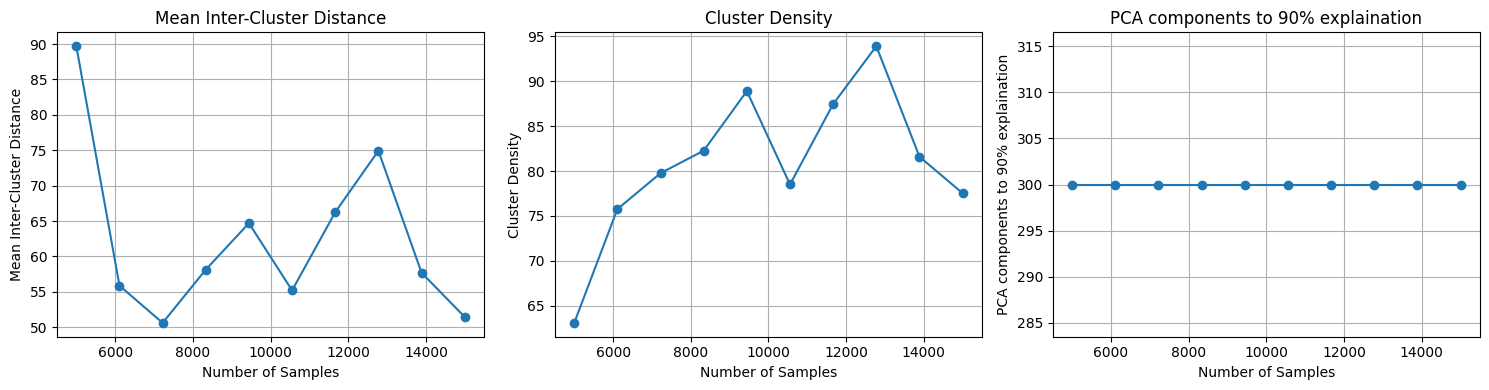

In [ ]:
# Plot results
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ("mean_inter_cluster_dist", "Mean Inter-Cluster Distance (Base yolov8n)"),
    ("cluster_density", "Cluster Density (Base yolov8n)"),
    ("pca_components_to_90", "PCA components to 90% explaination (Base yolov8n)"),
]

for i, (key, label) in enumerate(metrics):
    axs[i].plot(results["size"], results[key], marker='o')
    axs[i].set_title(label)
    axs[i].set_xlabel("Number of Samples")
    axs[i].set_ylabel(label)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

Intercluster Distance

<ipython-input-24-15af726d8c80>:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_exp, _ = curve_fit(exp_decay, N, y, maxfev=10000)


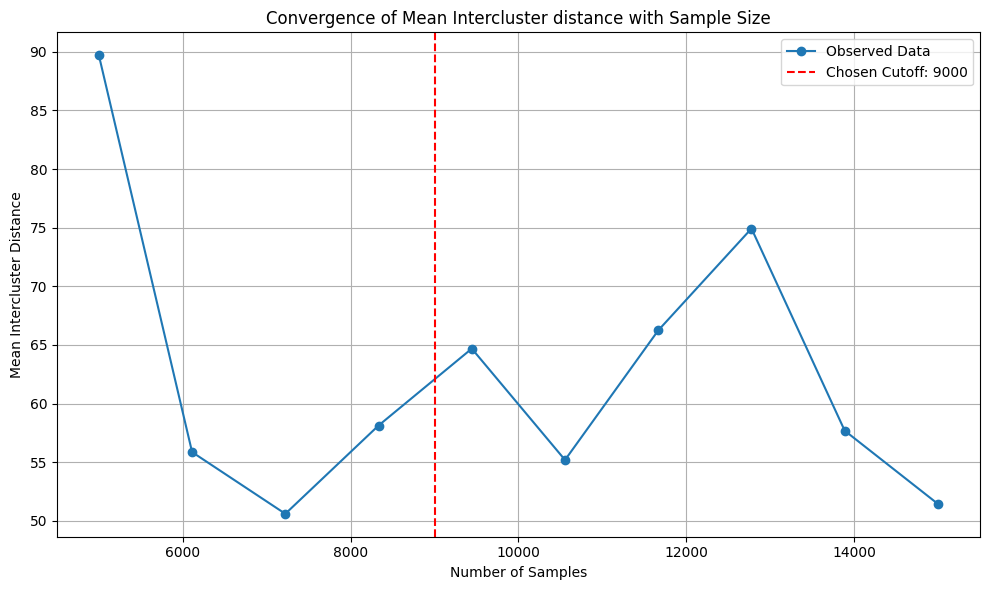

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.figure(figsize=(10, 6))
plt.plot(N, y, label="Data", marker='o')
plt.axvline(x=cutoff, color="red", linestyle="--", label=f"Cutoff: {cutoff}")

plt.xlabel("Number of Samples")
plt.ylabel("Mean Intercluster Distance")
plt.title("Convergence of Mean Intercluster distance with Sample Size")
plt.legend()
plt.grid(True)
plt.savefig("MICD_convergence_plot.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

Cluster Density

<ipython-input-26-91f233f582a8>:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_exp, _ = curve_fit(exp_decay, N, y, maxfev=10000)


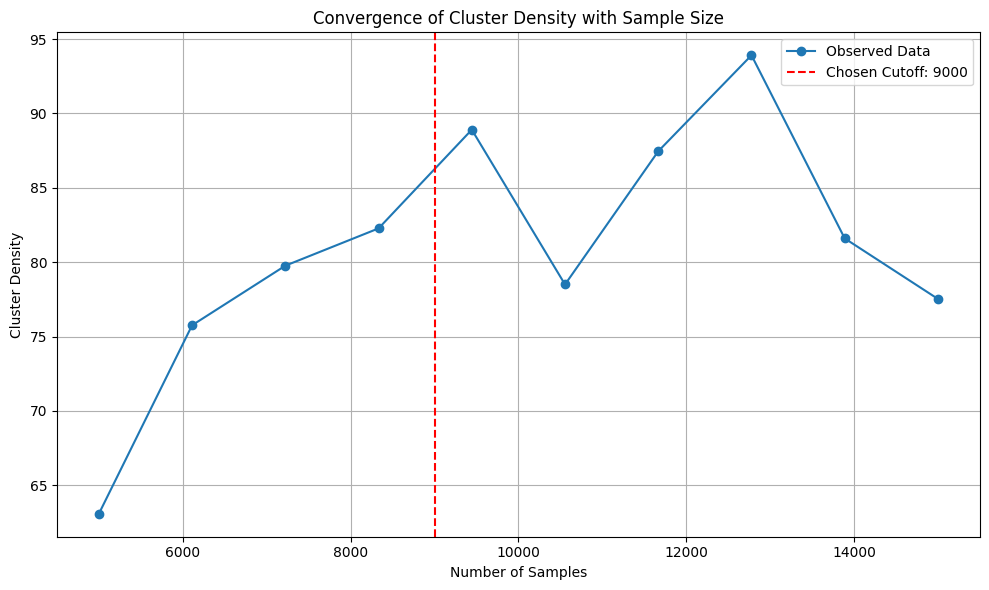

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


plt.figure(figsize=(10, 6))
plt.plot(N, y, label="Data", marker='o')
plt.axvline(x=cutoff, color="red", linestyle="--", label=f"Cutoff: {cutoff}")

plt.xlabel("Number of Samples")
plt.ylabel("Cluster Density")
plt.title("Convergence of Cluster Density with Sample Size")
plt.legend()
plt.savefig("CD_convergence_plot.png", dpi=300, bbox_inches="tight")
plt.show()

PC1-2

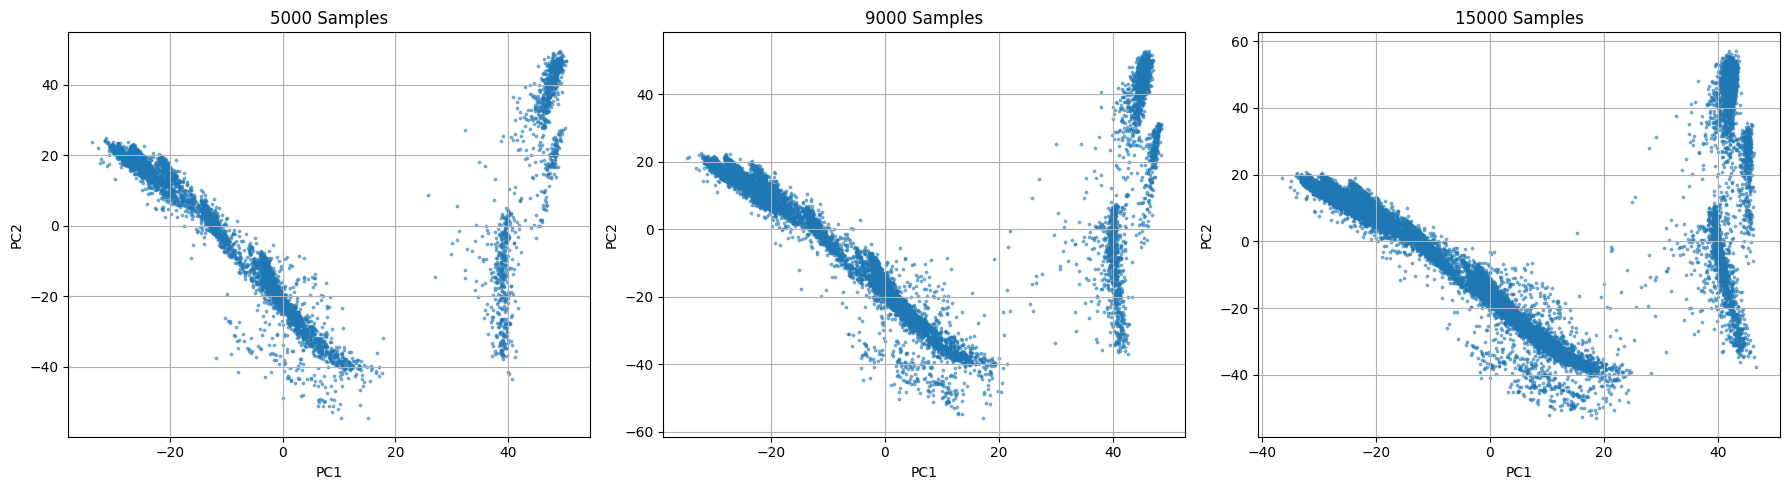

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random

# === Define sample sizes ===
sample_sizes = [5000, 9000, 15000]
titles = ["5000 Samples", "9000 Samples", "15000 Samples"]

# === Set up plot
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, size in enumerate(sample_sizes):
    indices = random.sample(range(X_all.shape[0]), size)
    X_subset = X_all[indices]

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_subset)

    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], s=3, alpha=0.5)
    axs[i].set_title(f"{titles[i]}")
    axs[i].set_xlabel("PC1")
    axs[i].set_ylabel("PC2")
    axs[i].grid(True)

plt.tight_layout()
plt.show()









# Contrast/Saturation Analysis

In [ ]:
#NEW LOOP train script


# Set the range of values for the parameters you want to loop over
hsv_h_values = [0.01, 0.02, 0.03]  # Hue (loop over 3 values)
hsv_s_values = [0.6, 0.75]         # Saturation (loop over 2 values)
hsv_v_values = [0.4, 0.45]



# Output project path for saving model runs
output_path = '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/'

# Looping training over values
for hsv_h in hsv_h_values:
    for hsv_s in hsv_s_values:
        for hsv_v in hsv_v_values:

            model_name = f"h{hsv_h}_s{hsv_s}_v{hsv_v}"
            model = YOLO("yolov8n.pt")
            pt_model = model.model
            print(f"Training model: {model_name}")


            model.train(
                data=yaml_path,
                epochs=10,  # Low epoch but compute biscuits expensive
                imgsz=640,
                lr0=0.01,
                lrf=0.0001,
                augment=True,
                hsv_h=hsv_h,  # Hue
                hsv_s=hsv_s,  # Saturation
                hsv_v=hsv_v,  # Brightness
                batch=16,
                project=output_path,  #Specify the save path for each run
                name=model_name
            )

            print(f"Completed training for {model_name}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set(style="whitegrid")

hsv_h_values = [0.01, 0.02, 0.03]  # Hue (loop over 3 values)
hsv_s_values = [0.6, 0.75]         # Saturation (loop over 2 values)
hsv_v_values = [0.4, 0.45]

# List of CSV file paths
csv_files = [
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.01_s0.6_v0.4_t0.1/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-preprocess/Reg/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-preprocess/BR0.5S1/results.csv',
    #'/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.01_s0.6_v0.4/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.01_s0.6_v0.45/results.csv',
    #'/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.01_s0.75_v0.4/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.01_s0.75_v0.45/results.csv',

    #'/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.02_s0.6_v0.4/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.02_s0.6_v0.45/results.csv',
    #'/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.02_s0.75_v0.4/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.02_s0.75_v0.45/results.csv',

    #'/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.03_s0.6_v0.4/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.03_s0.6_v0.45/results.csv',
    #'/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.03_s0.75_v0.4/results.csv',
    '/content/drive/MyDrive/ENDG511_Project_Data/1percent/models-yolo/h0.03_s0.75_v0.45/results.csv',


]

# Extract names from file paths for legend labels
model_names = [os.path.basename(os.path.dirname(path)) for path in csv_files]

# List of metrics to plot
metrics = [
    ('train/box_loss', 'Train Box Loss'),
    ('train/cls_loss', 'Train Class Loss'),
    ('metrics/mAP50(B)', 'mAP50'),
    ('metrics/mAP50-95(B)', 'mAP50-95'),
    ('metrics/precision(B)', 'Precision (B)'),
    ('metrics/recall(B)', 'Recall (B)')
]

# Load all CSVs into a dictionary with corresponding model names
data_frames = {model: pd.read_csv(file) for model, file in zip(model_names, csv_files)}

#PLotting seperate figures
for metric_column, metric_label in metrics:
    plt.figure(figsize=(10, 6))

    # Plot data for each model
    for model, df in data_frames.items():
        plt.plot(df['epoch'], df[metric_column], label=model)


    # Set labels, title, and legend
    plt.xlabel('Epoch')
    plt.ylabel(metric_label)
    plt.title(f'{metric_label} Across Epochs')
    plt.legend()

    # Show the plot
    plt.show()